In [7]:
import pandas as pd

df = pd.read_csv("Data/merged_customer_data.csv")



In [9]:
# basic cleanup for modeling
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Engagement Score'] = pd.to_numeric(df['Engagement Score'], errors='coerce')
df['Data Completeness %'] = pd.to_numeric(df['Data Completeness %'], errors='coerce')
df['Lifetime Value'] = pd.to_numeric(df['Lifetime Value'], errors='coerce')

# drop rows missing key fields
df = df.dropna(subset=['Customer ID', 'Transaction Date', 'Transaction ID', 'Revenue'])

# optional safety cleanup
df = df.drop_duplicates()

print(df.shape)
df.head()

(2500, 31)


,Transaction ID,Customer ID,Transaction Date,Business Line,Product/Service,Revenue,Data Source,Region,Source Type,Primary Business Line,...,Source ID,Business Line_ds,Data Source Name,Source Type_ds,Customer ID Available,Email Available,Demographics Available,Data Quality,Integration Status,Notes
0,TXN000001,CUST00150,2024-01-01,Consumer Products,Merchandise - Collectibles,54.06,3rd Party - Walmart,East Coast,3rd Party,Consumer Products,...,8,Consumer Products,3rd Party - Walmart,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
1,TXN000002,CUST00642,2024-01-01,Consumer Products,Merchandise - Apparel,40.87,3rd Party - Target,West Coast,3rd Party,Consumer Products,...,7,Consumer Products,3rd Party - Target,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
2,TXN000003,CUST00035,2024-01-01,Streaming,Monthly Subscription,10.72,1st Party - Streaming Platform,Southwest,1st Party,Streaming,...,1,Streaming,1st Party - Streaming Platform,1st Party,Yes,Yes,Yes (80% complete),High,Fully Integrated,Complete customer profiles with viewing history
3,TXN000004,CUST00163,2024-01-02,Theatrical,Mystery Manor,17.24,3rd Party - AMC Theatres,Southwest,3rd Party,Theatrical,...,4,Theatrical,3rd Party - AMC Theatres,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...
4,TXN000005,CUST00185,2024-01-02,Theatrical,Space Odyssey 2,27.81,3rd Party - Cinemark,East Coast,3rd Party,Theatrical,...,6,Theatrical,3rd Party - Cinemark,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...


In [11]:
# build customer-level features
ref_date = df['Transaction Date'].max() + pd.Timedelta(days=1)

features = (
    df.groupby('Customer ID')
      .agg(
          Recency=('Transaction Date', lambda x: (ref_date - x.max()).days),
          Frequency=('Transaction ID', 'nunique'),
          Monetary=('Revenue', 'sum'),
          Engagement_Score=('Engagement Score', 'max'),
          Data_Completeness=('Data Completeness %', 'max'),
          Lifetime_Value=('Lifetime Value', 'max'),
          Customer_Data_Type=('Customer Data Type', 'first')
      )
      .reset_index()
)

print(features.shape)
features.head()

(363, 8)


,Customer ID,Recency,Frequency,Monetary,Engagement_Score,Data_Completeness,Lifetime_Value,Customer_Data_Type
0,CUST00001,43,7,708.41,74,81,708.41,1st Party Only
1,CUST00002,47,8,1283.69,84,78,1283.69,Mixed (1st & 3rd Party)
2,CUST00003,178,3,124.72,0,77,124.72,1st Party Only
3,CUST00004,16,9,840.39,100,98,840.39,1st Party Only
4,CUST00005,90,4,412.37,26,87,412.37,1st Party Only


In [72]:
# create RFM-style risk label 
features['R_Score'] = pd.qcut(
    features['Recency'].rank(method='first'),
    3,
    labels=[3, 2, 1]
).astype(int)

features['F_Score'] = pd.qcut(
    features['Frequency'].rank(method='first'),
    3,
    labels=[1, 2, 3]
).astype(int)

features['M_Score'] = pd.qcut(
    features['Monetary'].rank(method='first'),
    3,
    labels=[1, 2, 3]
).astype(int)

features['RFM_Total'] = (
    features['R_Score'] +
    features['F_Score'] +
    features['M_Score']
)

def rfm_segment(score):
    if score >= 8:
        return 'Champions'
    elif score >= 6:
        return 'Loyal'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Low Value'

features['Segment'] = features['RFM_Total'].apply(rfm_segment)
features['is_at_risk'] = features['Segment'].isin(['At Risk', 'Low Value']).astype(int)

features[['Customer ID', 'Segment', 'is_at_risk']].head()

,Customer ID,Segment,is_at_risk
0,CUST00001,Loyal,0
1,CUST00002,Loyal,0
2,CUST00003,Low Value,1
3,CUST00004,Champions,0
4,CUST00005,At Risk,1


In [74]:
features.head()

,Customer ID,Recency,Frequency,Monetary,Engagement_Score,Data_Completeness,Lifetime_Value,Customer_Data_Type,R_Score,F_Score,M_Score,RFM_Total,Segment,is_at_risk,churn_probability
0,CUST00001,43,7,708.41,74,81,708.41,1st Party Only,2,2,2,6,Loyal,0,0.000
1,CUST00002,47,8,1283.69,84,78,1283.69,Mixed (1st & 3rd Party),2,2,3,7,Loyal,0,0.010
2,CUST00003,178,3,124.72,0,77,124.72,1st Party Only,1,1,1,3,Low Value,1,0.990
3,CUST00004,16,9,840.39,100,98,840.39,1st Party Only,3,2,3,8,Champions,0,0.000
4,CUST00005,90,4,412.37,26,87,412.37,1st Party Only,1,1,2,4,At Risk,1,0.985


In [15]:
# select model inputs and target
feature_cols = ['Recency', 'Frequency', 'Monetary', 'Engagement_Score', 'Data_Completeness']

X = features[feature_cols].copy()
y = features['is_at_risk'].copy()

print(X.isna().sum())
print(y.value_counts())
X.head()

Recency              0
Frequency            0
Monetary             0
Engagement_Score     0
Data_Completeness    0
dtype: int64
is_at_risk
0    213
1    150
Name: count, dtype: int64


,Recency,Frequency,Monetary,Engagement_Score,Data_Completeness
0,43,7,708.41,74,81
1,47,8,1283.69,84,78
2,178,3,124.72,0,77
3,16,9,840.39,100,98
4,90,4,412.37,26,87


In [17]:
# train/test split + random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[43  0]
 [ 0 30]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00        30

    accuracy                           1.00        73
   macro avg       1.00      1.00      1.00        73
weighted avg       1.00      1.00      1.00        73



In [19]:
# churn probability for every customer
features['churn_probability'] = rf.predict_proba(X)[:, 1]

print(features['churn_probability'].describe().round(3))
features[['Customer ID', 'Segment', 'churn_probability']].head()

count    363.000
mean       0.414
std        0.472
min        0.000
25%        0.000
50%        0.040
75%        1.000
max        1.000
Name: churn_probability, dtype: float64


,Customer ID,Segment,churn_probability
0,CUST00001,Loyal,0.000
1,CUST00002,Loyal,0.010
2,CUST00003,Low Value,0.990
3,CUST00004,Champions,0.000
4,CUST00005,At Risk,0.985


In [21]:
# merge business-value fields back in
features_rev = features.merge(
    df[['Customer ID', 'Lifetime Value', 'Customer Data Type']].drop_duplicates('Customer ID'),
    on='Customer ID',
    how='left'
)

features_rev.head()

,Customer ID,Recency,Frequency,Monetary,Engagement_Score,Data_Completeness,Lifetime_Value,Customer_Data_Type,R_Score,F_Score,M_Score,RFM_Total,Segment,is_at_risk,churn_probability,Lifetime Value,Customer Data Type
0,CUST00001,43,7,708.41,74,81,708.41,1st Party Only,2,2,2,6,Loyal,0,0.000,708.41,1st Party Only
1,CUST00002,47,8,1283.69,84,78,1283.69,Mixed (1st & 3rd Party),2,2,3,7,Loyal,0,0.010,1283.69,Mixed (1st & 3rd Party)
2,CUST00003,178,3,124.72,0,77,124.72,1st Party Only,1,1,1,3,Low Value,1,0.990,124.72,1st Party Only
3,CUST00004,16,9,840.39,100,98,840.39,1st Party Only,3,2,3,8,Champions,0,0.000,840.39,1st Party Only
4,CUST00005,90,4,412.37,26,87,412.37,1st Party Only,1,1,2,4,At Risk,1,0.985,412.37,1st Party Only


In [23]:
# highest-risk customers
at_risk_ranked = (
    features_rev[features_rev['is_at_risk'] == 1]
    .sort_values('churn_probability', ascending=False)
    [['Customer ID', 'churn_probability', 'Lifetime Value',
      'Customer Data Type', 'Recency', 'Frequency', 'Monetary']]
)

print(at_risk_ranked.head(10).to_string(index=False))

Customer ID  churn_probability  Lifetime Value Customer Data Type  Recency  Frequency  Monetary
  CUST00642                1.0           96.65     3rd Party Only       67          4     96.65
  CUST00640                1.0           25.69     3rd Party Only      110          1     25.69
  CUST00703                1.0          120.33     3rd Party Only       89          3    120.33
  CUST00704                1.0           22.34     3rd Party Only      298          1     22.34
  CUST00705                1.0           81.67     3rd Party Only      126          2     81.67
  CUST00708                1.0           18.30     3rd Party Only      189          1     18.30
  CUST00709                1.0          125.50     3rd Party Only      119          2    125.50
  CUST00710                1.0           58.62     3rd Party Only      201          3     58.62
  CUST00711                1.0           27.71     3rd Party Only      185          2     27.71
  CUST00712                1.0          

In [25]:
# revenue at stake
total_at_risk_ltv = features_rev.loc[
    features_rev['is_at_risk'] == 1, 'Lifetime Value'
].sum()

high_prob_at_risk = features_rev.loc[
    features_rev['churn_probability'] > 0.7, 'Lifetime Value'
].sum()

print(f"Total LTV at stake across all At-Risk/Low Value customers: ${total_at_risk_ltv:,.0f}")
print(f"LTV at stake for high-confidence at-risk (prob > 0.7): ${high_prob_at_risk:,.0f}")
print(f"Revenue recovered if 50% retention rate achieved: ${total_at_risk_ltv * 0.5:,.0f}")

Total LTV at stake across all At-Risk/Low Value customers: $22,274
LTV at stake for high-confidence at-risk (prob > 0.7): $20,168
Revenue recovered if 50% retention rate achieved: $11,137


In [27]:
# check the 3rd-party bias / data completeness issue
print("Avg churn probability by Customer Data Type:")
print(features_rev.groupby('Customer Data Type')['churn_probability'].mean().round(3))
print()

high_risk = features_rev[features_rev['churn_probability'] > 0.7]

print("High-risk customers (prob > 0.7) broken down by data type:")
print(high_risk['Customer Data Type'].value_counts())
print()

print("As a percentage of each data type:")
for dtype in features_rev['Customer Data Type'].dropna().unique():
    group = features_rev[features_rev['Customer Data Type'] == dtype]
    pct = (group['churn_probability'] > 0.7).mean()
    print(f"{dtype}: {pct:.1%}")

Avg churn probability by Customer Data Type:
Customer Data Type
1st Party Only             0.400
3rd Party Only             0.988
Mixed (1st & 3rd Party)    0.131
Name: churn_probability, dtype: float64

High-risk customers (prob > 0.7) broken down by data type:
Customer Data Type
3rd Party Only             112
Mixed (1st & 3rd Party)     26
1st Party Only               7
Name: count, dtype: int64

As a percentage of each data type:
1st Party Only: 36.8%
Mixed (1st & 3rd Party): 11.3%
3rd Party Only: 98.2%


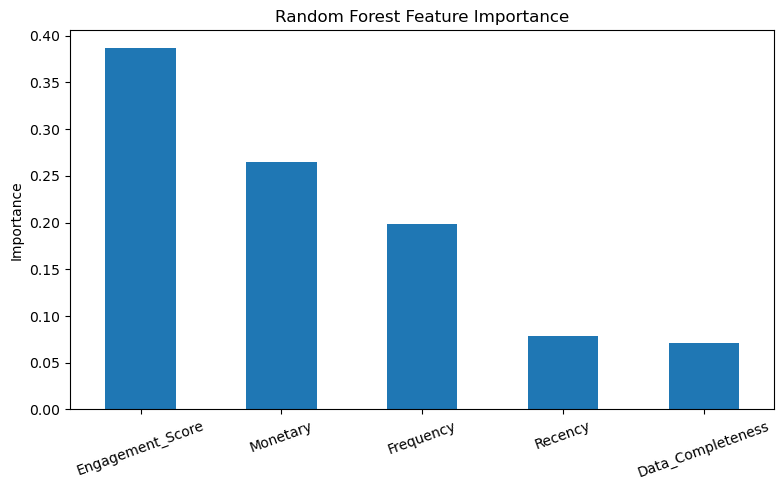

In [29]:
# feature importance
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='bar', ax=ax)
ax.set_title('Random Forest Feature Importance')
ax.set_ylabel('Importance')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## SHAP global importance

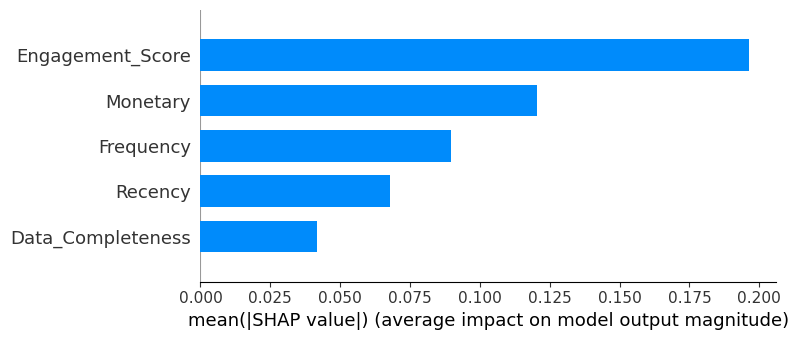

In [45]:
# SHAP global importance
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values[:, :, 1],
    X,
    feature_names=feature_cols,
    plot_type='bar'
)

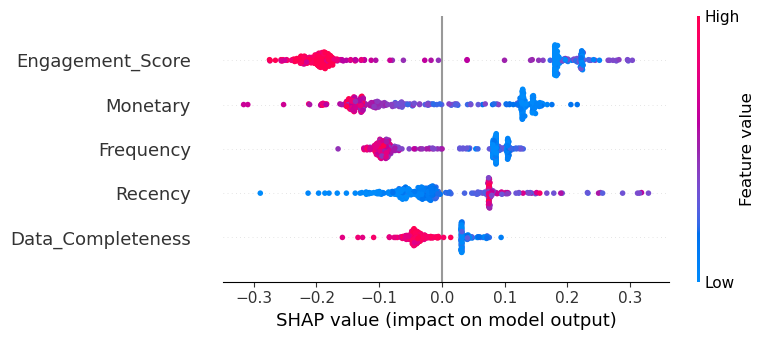

In [47]:
# SHAP direction of effects
shap.summary_plot(
    shap_values[:, :, 1],
    X,
    feature_names=feature_cols
)

## Look at one random customer

In [49]:
# explain one high-risk 3rd-party-only customer
top_risk_idx = features_rev[
    features_rev['Customer Data Type'] == '3rd Party Only'
]['churn_probability'].idxmax()

print(features_rev.loc[top_risk_idx, [
    'Customer ID', 'churn_probability', 'Lifetime Value',
    'Customer Data Type', 'Recency', 'Frequency',
    'Monetary', 'Data_Completeness'
]])

Customer ID                CUST00150
churn_probability                1.0
Lifetime Value                119.98
Customer Data Type    3rd Party Only
Recency                          111
Frequency                          2
Monetary                      119.98
Data_Completeness                 16
Name: 149, dtype: object


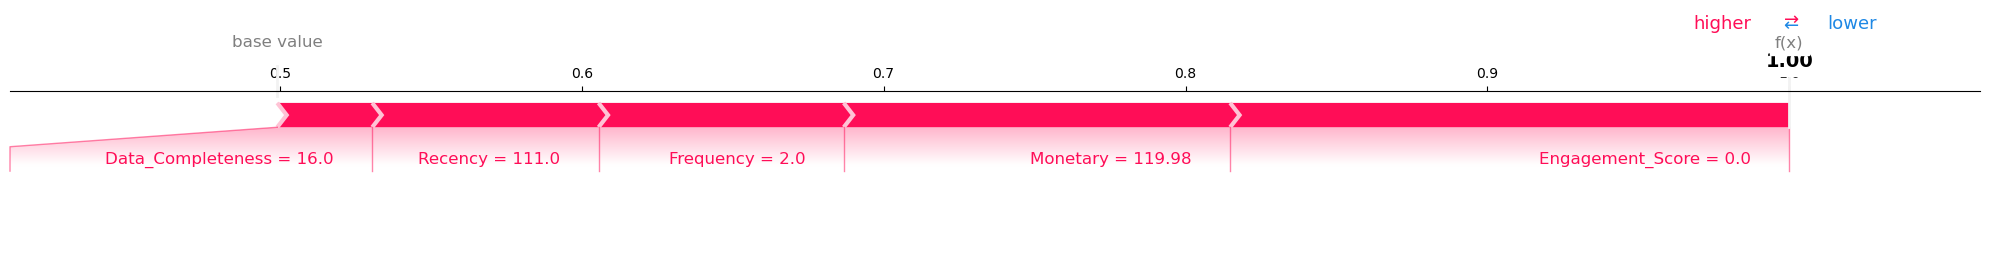

In [51]:
# SHAP explanation for that one customer
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[top_risk_idx, :, 1],
    X.iloc[top_risk_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)

plt.tight_layout()
plt.show()

# Model Evaluation

In [53]:
# core evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("PR AUC:", round(average_precision_score(y_test, y_prob), 3))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC AUC: 1.0
PR AUC: 1.0


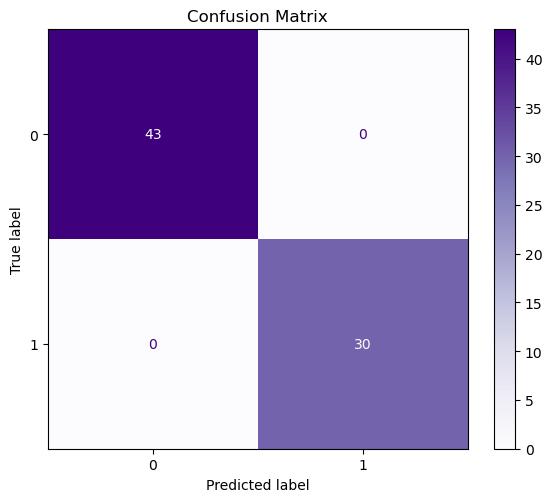

In [55]:
# confusion matrix heatmap
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Purples')
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

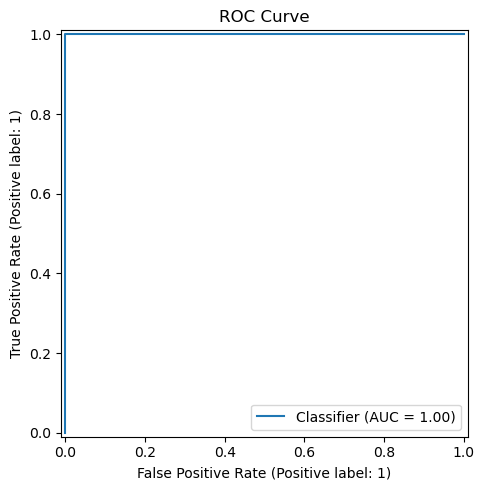

In [57]:
# ROC curve
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title("ROC Curve")
plt.tight_layout()
plt.show()

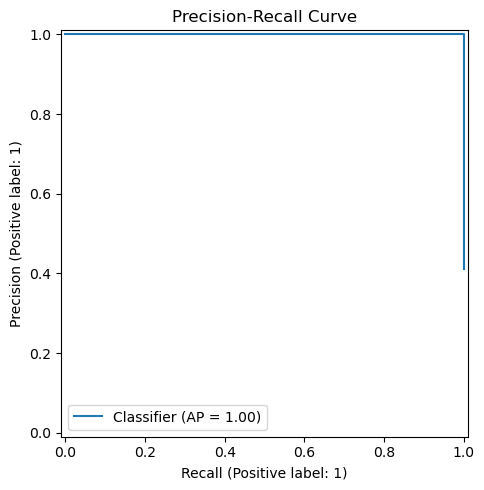

In [59]:
# precision-recall curve
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [61]:
# cross-validation for more stable performance
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf, X, y, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=False
)

for metric in ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']:
    print(metric, "mean =", round(cv_results[metric].mean(), 3),
          "| std =", round(cv_results[metric].std(), 3))

test_accuracy mean = 0.967 | std = 0.024
test_precision mean = 0.95 | std = 0.043
test_recall mean = 0.973 | std = 0.025
test_f1 mean = 0.961 | std = 0.028
test_roc_auc mean = 0.996 | std = 0.004


In [63]:
# attach test predictions back to customer type
test_results = features.loc[X_test.index, ['Customer_Data_Type', 'is_at_risk']].copy()
test_results['y_true'] = y_test.values
test_results['y_pred'] = y_pred
test_results['y_prob'] = y_prob

test_results.head()

,Customer_Data_Type,is_at_risk,y_true,y_pred,y_prob
233,Mixed (1st & 3rd Party),0,0,0,0.170
302,3rd Party Only,1,1,1,0.925
97,Mixed (1st & 3rd Party),0,0,0,0.000
153,Mixed (1st & 3rd Party),0,0,0,0.000
309,3rd Party Only,1,1,1,1.000


In [65]:
# subgroup metrics by customer type
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rows = []

for dtype, group in test_results.groupby('Customer_Data_Type'):
    if group['y_true'].nunique() < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(group['y_true'], group['y_prob'])
        
    rows.append({
        'Customer Data Type': dtype,
        'Count': len(group),
        'Accuracy': accuracy_score(group['y_true'], group['y_pred']),
        'Precision': precision_score(group['y_true'], group['y_pred'], zero_division=0),
        'Recall': recall_score(group['y_true'], group['y_pred'], zero_division=0),
        'F1': f1_score(group['y_true'], group['y_pred'], zero_division=0),
        'ROC AUC': auc,
        'Avg Predicted Risk': group['y_prob'].mean()
    })

subgroup_eval = pd.DataFrame(rows).round(3)
subgroup_eval

,Customer Data Type,Count,Accuracy,Precision,Recall,F1,ROC AUC,Avg Predicted Risk
0,1st Party Only,2,1.0,0.0,0.0,0.0,NaN,0.00
1,3rd Party Only,25,1.0,1.0,1.0,1.0,1.0,0.96
2,Mixed (1st & 3rd Party),46,1.0,1.0,1.0,1.0,1.0,0.13


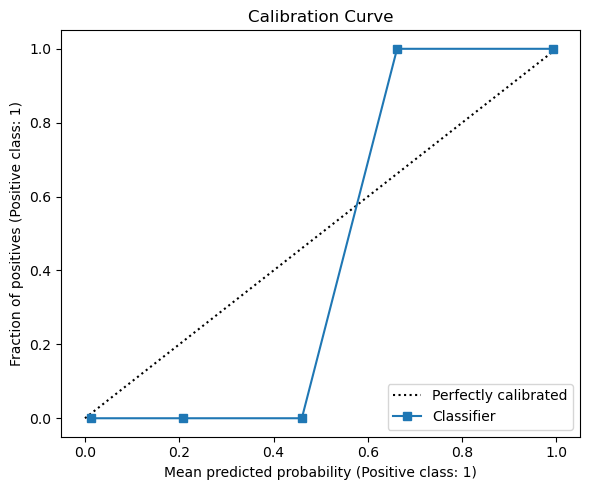

In [67]:
# calibration curve
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=8, ax=ax)
ax.set_title("Calibration Curve")
plt.tight_layout()
plt.show()